In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lm_polygraph.ue_metrics.pred_rej_area import PredictionRejectionArea
from lm_polygraph.ue_metrics.ue_metric import (
    get_random_scores,
    normalize_metric,
)
import sklearn
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from collections import defaultdict
from sacrebleu import CHRF, BLEU
from utils import extract_and_prepare_data

/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [4]:
methods_dict = {
    'MaximumSequenceProbability': 'MSP',
    'Perplexity': 'PPL',
    'MeanTokenEntropy': 'MTE',
    'MonteCarloSequenceEntropy': 'MCSE',
    'MonteCarloNormalizedSequenceEntropy': 'MCNSE',
}

DATASETS = [
    # 'wmt14_csen',
    # 'wmt14_ruen',
    'xsum'
]

all_metrics = ['AlignScoreInputOutput', '']

Loading NLI model...


/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f04be91bb80>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f04be94bf70>]


IndexError: boolean index did not match indexed array along dimension 0; dimension is 0 but corresponding boolean dimension is 2000

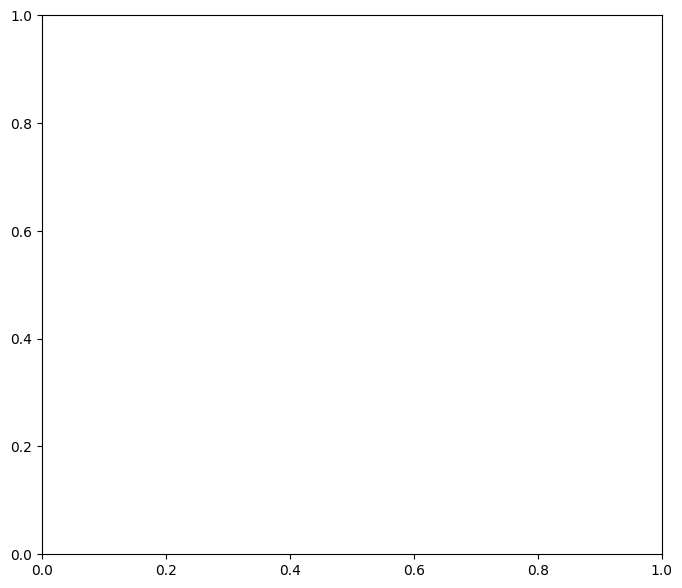

In [5]:
for dataset in DATASETS:
    train_ue_values, \
    test_ue_values, \
    train_metric_values, \
    test_metric_values, \
    train_gen_lengths, \
    test_gen_lengths = extract_and_prepare_data(dataset, methods_dict, all_metrics, model='xsum')

    upper_q = np.quantile(train_gen_lengths, 0.95)
    lower_q = np.quantile(train_gen_lengths, 0.05)
    below_q_ids = (train_gen_lengths < upper_q) & (train_gen_lengths > lower_q)
    train_gen_lengths = train_gen_lengths[below_q_ids]

    train_normalized_metric_values = {}
    test_normalized_metric_values = {}

    # Train Data Plot
    fig, axs = plt.subplots(1, len(all_metrics), figsize=(8 * len(all_metrics), 7))
    
    for i, metric in enumerate(all_metrics):
        gen_length_scaler = MinMaxScaler()
        train_gen_lengths_normalized = gen_length_scaler.fit_transform(train_gen_lengths[:, np.newaxis]).squeeze()

        # Normalize train metrics
        train_metric = train_metric_values[metric][below_q_ids]
        scaler = MinMaxScaler()
        train_normalized_metric_values[metric] = scaler.fit_transform(train_metric[:, np.newaxis]).squeeze()

        # Average values for each unique generated sequence length
        unique_lengths = np.unique(train_gen_lengths_normalized)
        avg_train_metric_values = []
        avg_train_gen_lengths_normalized = []

        for length in unique_lengths:
            idx = np.isclose(train_gen_lengths_normalized, length)
            avg_train_metric_values.append(np.mean(train_normalized_metric_values[metric][idx]))
            avg_train_gen_lengths_normalized.append(length)

        avg_train_metric_values = np.array(avg_train_metric_values)
        avg_train_gen_lengths_normalized = np.array(avg_train_gen_lengths_normalized)

        # Compute moving average
        window_size = 10
        moving_avg = pd.Series(avg_train_metric_values).rolling(window=window_size, min_periods=1).mean()

        # Fit linear regression on averaged values
        train_linreg = sklearn.linear_model.LinearRegression()
        train_linreg.fit(avg_train_gen_lengths_normalized[:, np.newaxis], avg_train_metric_values)
        coef = train_linreg.coef_[0]

        # Fit linear regression on non-averaged data (raw data)
        raw_linreg = sklearn.linear_model.LinearRegression()
        raw_linreg.fit(train_gen_lengths_normalized[:, np.newaxis], train_normalized_metric_values[metric])

        ax = axs[i]
        ax.plot(avg_train_gen_lengths_normalized, avg_train_metric_values, label='train (averaged)', color='blue')
        ax.plot(avg_train_gen_lengths_normalized, moving_avg, label=f'Moving Average (window={window_size})', color='orange')
        ax.plot(avg_train_gen_lengths_normalized, train_linreg.predict(avg_train_gen_lengths_normalized[:, np.newaxis]), label=f'avg_pred: {round(coef, 3)}', color='green')
        ax.plot(train_gen_lengths_normalized, raw_linreg.predict(train_gen_lengths_normalized[:, np.newaxis]), label=f'raw_pred: {round(raw_linreg.coef_[0], 3)}', color='red')

        ax.legend()
        ax.set_title(f'{metric} (Train Data)')
        ax.set_xlabel('Generated sequence length (Normalized)')
        ax.set_ylabel('Metric value (Normalized)')

    fig.suptitle(f'{dataset} - Train Data')
    plt.tight_layout()
    plt.savefig(f'metric_train_{dataset}.png')
    plt.show()
      # Saves as a PNG file

    upper_q_test = np.quantile(test_gen_lengths, 0.95)
    lower_q_test = np.quantile(test_gen_lengths, 0.05)
    below_q_ids_test = (test_gen_lengths < upper_q_test) & (test_gen_lengths > lower_q_test)
    test_gen_lengths = test_gen_lengths[below_q_ids_test]


    # Test Data Plot (Separate figure)
    fig, axs = plt.subplots(1, len(all_metrics), figsize=(8 * len(all_metrics), 7))
    for i, metric in enumerate(all_metrics):
    # Normalize test sequence lengths using a separate MinMaxScaler for test data
        test_gen_length_scaler = MinMaxScaler()
        test_gen_lengths_normalized = test_gen_length_scaler.fit_transform(test_gen_lengths[:, np.newaxis]).squeeze()

        # Normalize test metrics using a new scaler for test data
        test_metric = test_metric_values[metric][below_q_ids_test]
        scaler_test = MinMaxScaler()
        test_normalized_metric_values[metric] = scaler_test.fit_transform(test_metric[:, np.newaxis]).squeeze()

        # Average values for each unique generated sequence length in the test data
        unique_lengths = np.unique(test_gen_lengths_normalized)
        avg_test_metric_values = []
        avg_test_gen_lengths_normalized = []

        for length in unique_lengths:
            idx = np.isclose(test_gen_lengths_normalized, length)
            avg_test_metric_values.append(np.mean(test_normalized_metric_values[metric][idx]))
            avg_test_gen_lengths_normalized.append(length)

        avg_test_metric_values = np.array(avg_test_metric_values)
        avg_test_gen_lengths_normalized = np.array(avg_test_gen_lengths_normalized)

        # Compute moving average for test data
        moving_avg_test = pd.Series(avg_test_metric_values).rolling(window=window_size, min_periods=1).mean()

        # Fit linear regression on averaged values for test data
        test_linreg = sklearn.linear_model.LinearRegression()
        test_linreg.fit(avg_test_gen_lengths_normalized[:, np.newaxis], avg_test_metric_values)
        coef = test_linreg.coef_[0]

        # Fit linear regression on non-averaged (raw) test data
        raw_linreg_test = sklearn.linear_model.LinearRegression()
        raw_linreg_test.fit(test_gen_lengths_normalized[:, np.newaxis], test_normalized_metric_values[metric])

        ax = axs[i]
        ax.plot(avg_test_gen_lengths_normalized, avg_test_metric_values, label='test (averaged)', color='blue')
        ax.plot(avg_test_gen_lengths_normalized, moving_avg_test, label=f'Moving Average (window={window_size})', color='orange')
        ax.plot(avg_test_gen_lengths_normalized, test_linreg.predict(avg_test_gen_lengths_normalized[:, np.newaxis]), label=f'avg_pred: {round(coef, 3)}', color='green')
        ax.plot(avg_test_gen_lengths_normalized, raw_linreg_test.predict(avg_test_gen_lengths_normalized[:, np.newaxis]), label=f'raw_pred: {round(raw_linreg_test.coef_[0], 3)}', color='red')

        ax.legend()
        ax.set_title(f'{metric} (Test Data)')
        ax.set_xlabel('Generated sequence length (Normalized)')
        ax.set_ylabel('Metric value (Normalized)')

    fig.suptitle(f'{dataset} - Test Data')
    plt.tight_layout()
    plt.savefig(f'metric_test_{dataset}.png')
    plt.show()
      # Saves as a PNG file




Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f0394ea9180>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f038a2c2f80>]


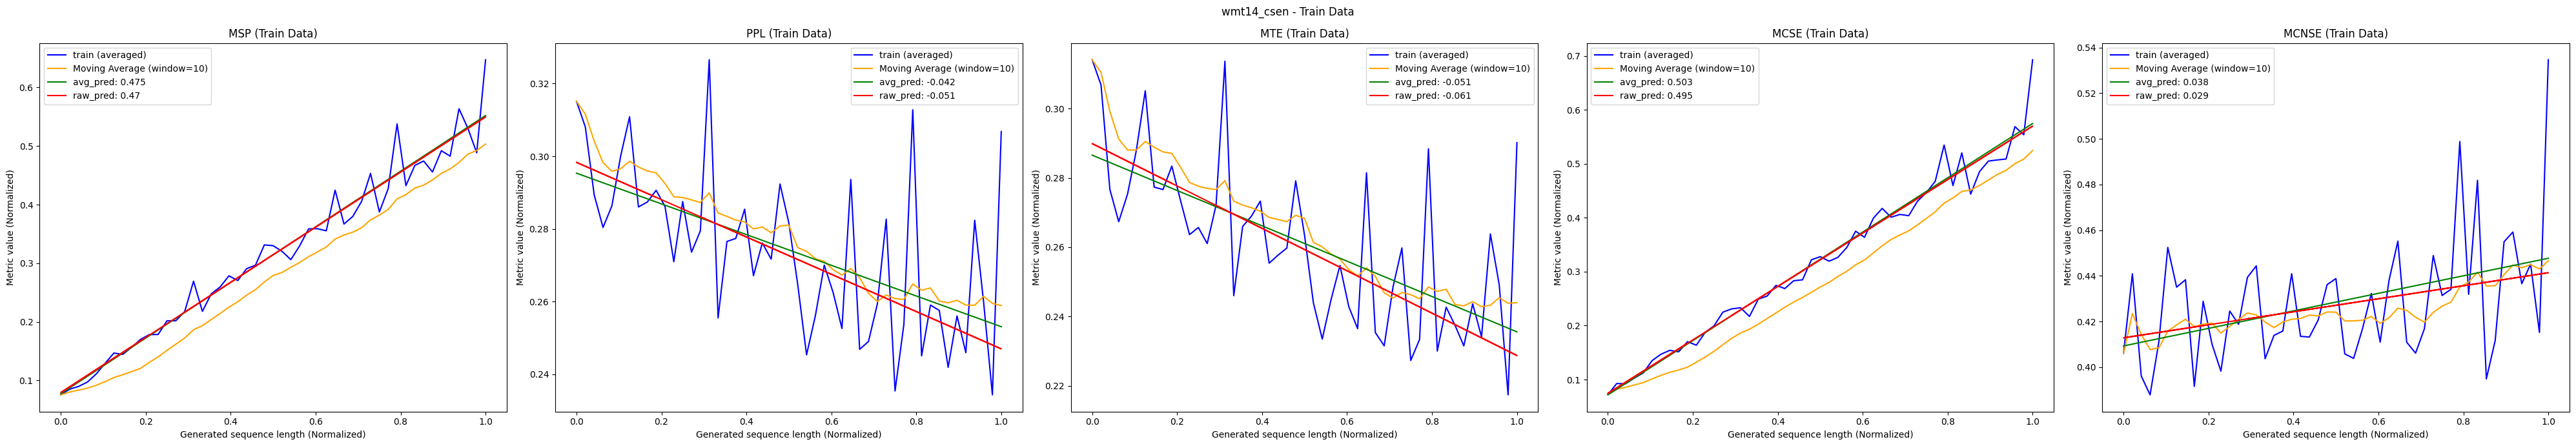

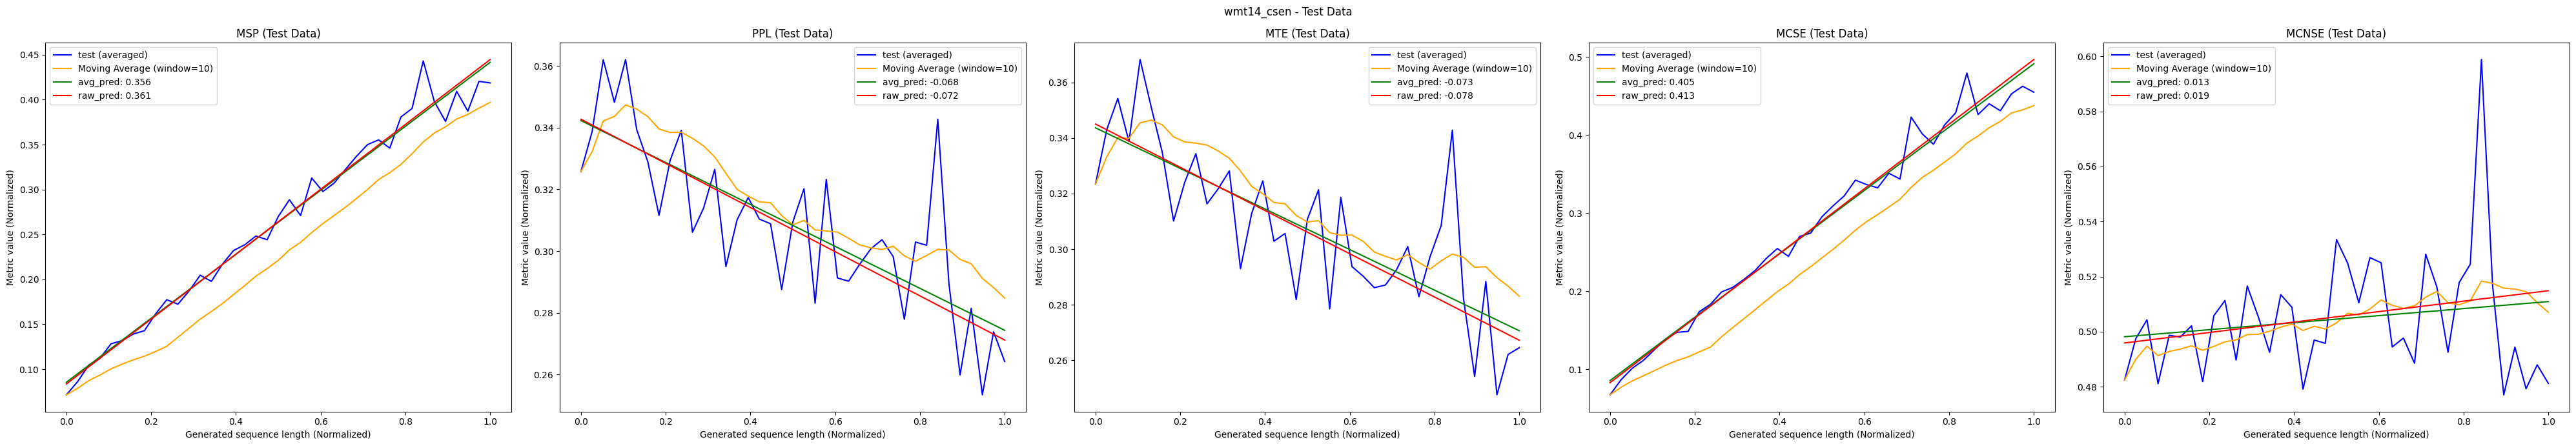

Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f0394e275e0>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f03950ab8e0>]


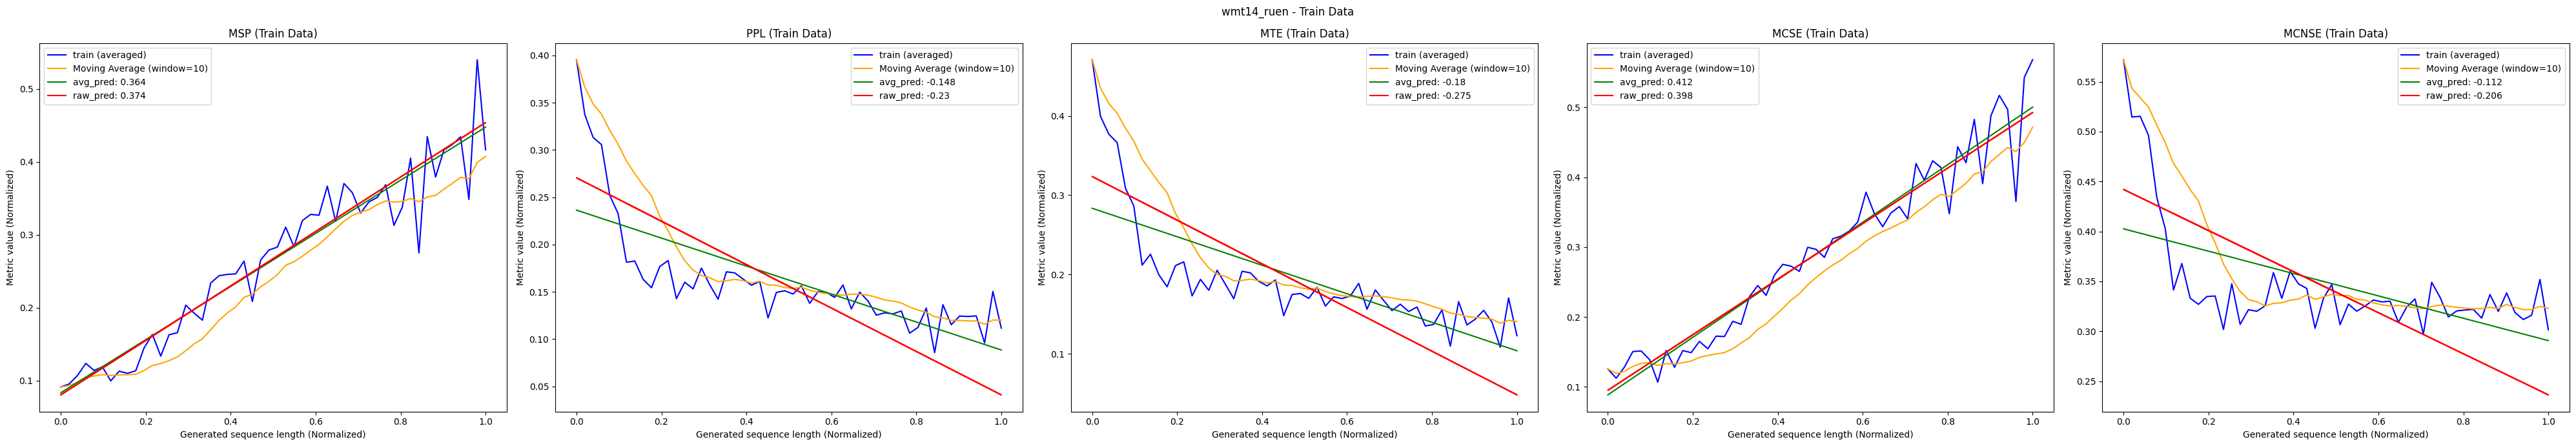

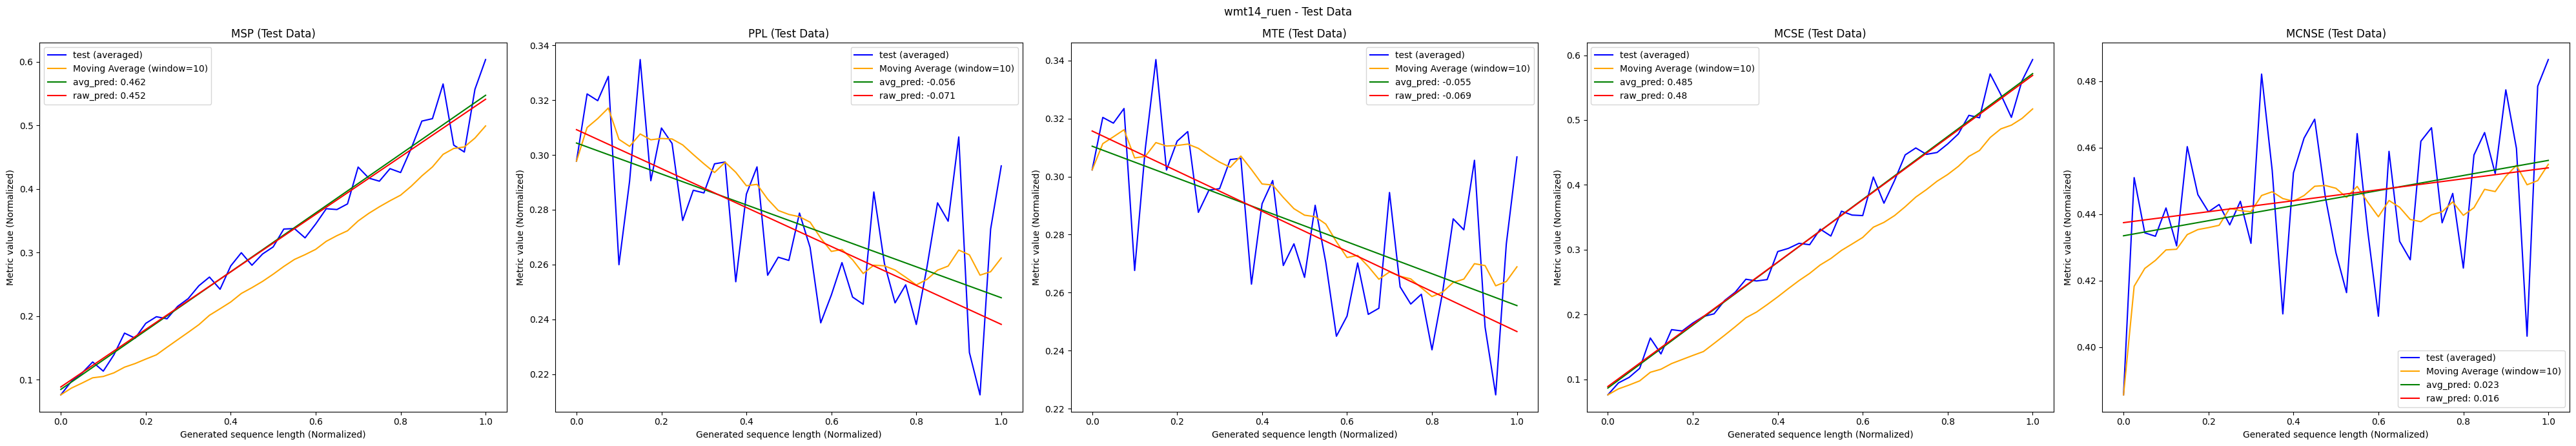

In [5]:
for dataset in DATASETS:
    train_ue_values, \
    test_ue_values, \
    train_metric_values, \
    test_metric_values, \
    train_gen_lengths, \
    test_gen_lengths = extract_and_prepare_data(dataset, methods_dict, all_metrics, model='llama1b')

    upper_q = np.quantile(train_gen_lengths, 0.95)
    lower_q = np.quantile(train_gen_lengths, 0.05)
    below_q_ids = (train_gen_lengths < upper_q) & (train_gen_lengths > lower_q)
    train_gen_lengths = train_gen_lengths[below_q_ids]

    train_normalized_metric_values = {}
    test_normalized_metric_values = {}
    all_methods = list(train_ue_values.keys())
    # Train Data Plot
    fig, axs = plt.subplots(1, len(all_methods), figsize=(8 * len(all_methods), 7))
    
    for i, metric in enumerate(all_methods):
        try:
            gen_length_scaler = MinMaxScaler()
            train_gen_lengths_normalized = gen_length_scaler.fit_transform(train_gen_lengths[:, np.newaxis]).squeeze()

            # Normalize train metrics
            train_metric = train_ue_values[metric][below_q_ids]
            scaler = MinMaxScaler()
            train_normalized_metric_values[metric] = scaler.fit_transform(train_metric[:, np.newaxis]).squeeze()

            # Average values for each unique generated sequence length
            unique_lengths = np.unique(train_gen_lengths_normalized)
            avg_train_metric_values = []
            avg_train_gen_lengths_normalized = []

            for length in unique_lengths:
                idx = np.isclose(train_gen_lengths_normalized, length)
                avg_train_metric_values.append(np.mean(train_normalized_metric_values[metric][idx]))
                avg_train_gen_lengths_normalized.append(length)

            avg_train_metric_values = np.array(avg_train_metric_values)
            avg_train_gen_lengths_normalized = np.array(avg_train_gen_lengths_normalized)

            # Compute moving average
            window_size = 10
            moving_avg = pd.Series(avg_train_metric_values).rolling(window=window_size, min_periods=1).mean()

            # Fit linear regression on averaged values
            train_linreg = sklearn.linear_model.LinearRegression()
            train_linreg.fit(avg_train_gen_lengths_normalized[:, np.newaxis], avg_train_metric_values)
            coef = train_linreg.coef_[0]

            # Fit linear regression on non-averaged data (raw data)
            raw_linreg = sklearn.linear_model.LinearRegression()
            raw_linreg.fit(train_gen_lengths_normalized[:, np.newaxis], train_normalized_metric_values[metric])

            ax = axs[i]
            ax.plot(avg_train_gen_lengths_normalized, avg_train_metric_values, label='train (averaged)', color='blue')
            ax.plot(avg_train_gen_lengths_normalized, moving_avg, label=f'Moving Average (window={window_size})', color='orange')
            ax.plot(avg_train_gen_lengths_normalized, train_linreg.predict(avg_train_gen_lengths_normalized[:, np.newaxis]), label=f'avg_pred: {round(coef, 3)}', color='green')
            ax.plot(train_gen_lengths_normalized, raw_linreg.predict(train_gen_lengths_normalized[:, np.newaxis]), label=f'raw_pred: {round(raw_linreg.coef_[0], 3)}', color='red')

            ax.legend()
            ax.set_title(f'{metric} (Train Data)')
            ax.set_xlabel('Generated sequence length (Normalized)')
            ax.set_ylabel('Metric value (Normalized)')
        except Exception as ex:
            print(f"Exception: {ex}\n values: {len(train_ue_values[metric])} , lengths: {len(train_gen_lengths)}")

    fig.suptitle(f'{dataset} - Train Data')
    plt.tight_layout()
    plt.savefig(f'UE_train_{dataset}.png')
    plt.show()

    upper_q_test = np.quantile(test_gen_lengths, 0.95)
    lower_q_test = np.quantile(test_gen_lengths, 0.05)
    below_q_ids_test = (test_gen_lengths < upper_q_test) & (test_gen_lengths > lower_q_test)
    test_gen_lengths = test_gen_lengths[below_q_ids_test]


    # Test Data Plot (Separate figure)
    fig, axs = plt.subplots(1, len(all_methods), figsize=(8 * len(all_methods), 7))
    for i, metric in enumerate(all_methods):
    # Normalize test sequence lengths using a separate MinMaxScaler for test data
        test_gen_length_scaler = MinMaxScaler()
        test_gen_lengths_normalized = test_gen_length_scaler.fit_transform(test_gen_lengths[:, np.newaxis]).squeeze()

        # Normalize test metrics using a new scaler for test data
        test_metric = test_ue_values[metric][below_q_ids_test]
        scaler_test = MinMaxScaler()
        test_normalized_metric_values[metric] = scaler_test.fit_transform(test_metric[:, np.newaxis]).squeeze()

        # Average values for each unique generated sequence length in the test data
        unique_lengths = np.unique(test_gen_lengths_normalized)
        avg_test_metric_values = []
        avg_test_gen_lengths_normalized = []

        for length in unique_lengths:
            idx = np.isclose(test_gen_lengths_normalized, length)
            avg_test_metric_values.append(np.mean(test_normalized_metric_values[metric][idx]))
            avg_test_gen_lengths_normalized.append(length)

        avg_test_metric_values = np.array(avg_test_metric_values)
        avg_test_gen_lengths_normalized = np.array(avg_test_gen_lengths_normalized)

        # Compute moving average for test data
        moving_avg_test = pd.Series(avg_test_metric_values).rolling(window=window_size, min_periods=1).mean()

        # Fit linear regression on averaged values for test data
        test_linreg = sklearn.linear_model.LinearRegression()
        test_linreg.fit(avg_test_gen_lengths_normalized[:, np.newaxis], avg_test_metric_values)
        coef = test_linreg.coef_[0]

        # Fit linear regression on non-averaged (raw) test data
        raw_linreg_test = sklearn.linear_model.LinearRegression()
        raw_linreg_test.fit(test_gen_lengths_normalized[:, np.newaxis], test_normalized_metric_values[metric])

        ax = axs[i]
        ax.plot(avg_test_gen_lengths_normalized, avg_test_metric_values, label='test (averaged)', color='blue')
        ax.plot(avg_test_gen_lengths_normalized, moving_avg_test, label=f'Moving Average (window={window_size})', color='orange')
        ax.plot(avg_test_gen_lengths_normalized, test_linreg.predict(avg_test_gen_lengths_normalized[:, np.newaxis]), label=f'avg_pred: {round(coef, 3)}', color='green')
        ax.plot(avg_test_gen_lengths_normalized, raw_linreg_test.predict(avg_test_gen_lengths_normalized[:, np.newaxis]), label=f'raw_pred: {round(raw_linreg_test.coef_[0], 3)}', color='red')

        ax.legend()
        ax.set_title(f'{metric} (Test Data)')
        ax.set_xlabel('Generated sequence length (Normalized)')
        ax.set_ylabel('Metric value (Normalized)')

    fig.suptitle(f'{dataset} - Test Data')
    plt.tight_layout()
    plt.savefig(f'UE_test_{dataset}.png')
    plt.show()



In [4]:
import numpy as np
import sklearn.linear_model
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import t

n_bootstrap = 1000  # Number of bootstrap samples
bootstrap_results = {}

for dataset in DATASETS:
    train_ue_values, \
    test_ue_values, \
    train_metric_values, \
    test_metric_values, \
    train_gen_lengths, \
    test_gen_lengths = extract_and_prepare_data(dataset, methods_dict, all_metrics, model='llama1b')

    # Filter based on quantiles
    upper_q = np.quantile(train_gen_lengths, 0.95)
    lower_q = np.quantile(train_gen_lengths, 0.05)
    below_q_ids = (train_gen_lengths < upper_q) & (train_gen_lengths > lower_q)
    train_gen_lengths = train_gen_lengths[below_q_ids]

    upper_q_test = np.quantile(test_gen_lengths, 0.95)
    lower_q_test = np.quantile(test_gen_lengths, 0.05)
    below_q_ids_test = (test_gen_lengths < upper_q_test) & (test_gen_lengths > lower_q_test)
    test_gen_lengths = test_gen_lengths[below_q_ids_test]

    dataset_results = {}

    for metric in train_ue_values.keys():
        try:
            # Normalize sequence lengths
            gen_length_scaler = MinMaxScaler()
            train_gen_lengths_normalized = gen_length_scaler.fit_transform(train_gen_lengths[:, np.newaxis]).squeeze()

            gen_length_scaler_test = MinMaxScaler()
            test_gen_lengths_normalized = gen_length_scaler_test.fit_transform(test_gen_lengths[:, np.newaxis]).squeeze()

            # Normalize metric values
            train_metric = train_ue_values[metric][below_q_ids]
            scaler = MinMaxScaler()
            train_normalized_metric_values = scaler.fit_transform(train_metric[:, np.newaxis]).squeeze()

            test_metric = test_ue_values[metric][below_q_ids_test]
            scaler_test = MinMaxScaler()
            test_normalized_metric_values = scaler_test.fit_transform(test_metric[:, np.newaxis]).squeeze()

            # Bootstrap Linear Regression Coefficients
            bootstrap_coefs = []
            bootstrap_coefs_test = []
            for _ in range(n_bootstrap):
                # Bootstrap train data
                boot_idx = np.random.choice(len(train_gen_lengths_normalized), size=len(train_gen_lengths_normalized), replace=True)
                boot_x = train_gen_lengths_normalized[boot_idx]
                boot_y = train_normalized_metric_values[boot_idx]

                boot_model = sklearn.linear_model.LinearRegression()
                boot_model.fit(boot_x[:, np.newaxis], boot_y)
                bootstrap_coefs.append(boot_model.coef_[0])  # Append only once

                # Bootstrap test data
                boot_idx_test = np.random.choice(len(test_gen_lengths_normalized), size=len(test_gen_lengths_normalized), replace=True)
                boot_x_test = test_gen_lengths_normalized[boot_idx_test]
                boot_y_test = test_normalized_metric_values[boot_idx_test]

                boot_model_test = sklearn.linear_model.LinearRegression()
                boot_model_test.fit(boot_x_test[:, np.newaxis], boot_y_test)
                bootstrap_coefs_test.append(boot_model_test.coef_[0])  # Append only once

            # Convert bootstrap coefficients to numpy arrays
            bootstrap_coefs = np.array(bootstrap_coefs)
            bootstrap_coefs_test = np.array(bootstrap_coefs_test)

            # Compute mean and standard deviation
            mean_coef = np.mean(bootstrap_coefs)
            std_coef = np.std(bootstrap_coefs, ddof=1)  # Sample std deviation
            mean_coef_test = np.mean(bootstrap_coefs_test)
            std_coef_test = np.std(bootstrap_coefs_test, ddof=1)

            # Compute Standard Errors
            se_coef = std_coef / np.sqrt(n_bootstrap)
            se_coef_test = std_coef_test / np.sqrt(n_bootstrap)

            # Compute t-critical value
            t_crit = t.ppf(0.975, df=n_bootstrap - 1)  # 95% CI, two-tailed
            ci_lower = mean_coef - t_crit * se_coef
            ci_upper = mean_coef + t_crit * se_coef

            ci_lower_test = mean_coef_test - t_crit * se_coef_test
            ci_upper_test = mean_coef_test + t_crit * se_coef_test

            dataset_results[metric] = {
                "mean_coef": mean_coef,
                "std_coef": std_coef,
                "95%_CI": (ci_lower, ci_upper),
                "mean_coef_test": mean_coef_test,
                "std_coef_test": std_coef_test,
                "95%_CI_test": (ci_lower_test, ci_upper_test),
                "all_bootstrap_coefs": bootstrap_coefs,  # Store full bootstrap distribution if needed
                "all_bootstrap_coefs_test": bootstrap_coefs_test  # Store full bootstrap distribution if needed
            }

        except Exception as ex:
            print(f"Exception: {ex}\n values: {len(train_ue_values[metric])} , lengths: {len(train_gen_lengths)}")

    bootstrap_results[dataset] = dataset_results

# Display final results
for dataset, results in bootstrap_results.items():
    print(f"\nDataset: {dataset}")
    for metric, stats in results.items():
        print(f"  Metric: {metric}")
        print(f"    Mean Coef: {stats['mean_coef']:.3f}")
        print(f"    Mean Coef Test: {stats['mean_coef_test']:.3f}")
        print(f"    Std Dev Coef: {stats['std_coef']:.3f}")
        print(f"    Std Dev Coef Test: {stats['std_coef_test']:.3f}")
        print(f"    95% CI: ({stats['95%_CI'][0]:.3f}, {stats['95%_CI'][1]:.3f})")
        print(f"    95% CI Test: ({stats['95%_CI_test'][0]:.3f}, {stats['95%_CI_test'][1]:.3f})")


Loading NLI model...


/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81b7580>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81e8a00>]


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81981f0>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f9273ffc9d0>]

Dataset: wmt14_csen
  Metric: MSP
    Mean Coef: 0.470
    Mean Coef Test: 0.361
    Std Dev Coef: 0.010
    Std Dev Coef Test: 0.009
    95% CI: (0.470, 0.471)
    95% CI Test: (0.360, 0.362)
  Metric: PPL
    Mean Coef: -0.051
    Mean Coef Test: -0.071
    Std Dev Coef: 0.010
    Std Dev Coef Test: 0.013
    95% CI: (-0.052, -0.050)
    95% CI Test: (-0.072, -0.071)
  Metric: MTE
    Mean Coef: -0.061
    Mean Coef Test: -0.077
    Std Dev Coef: 0.009
    Std Dev Coef Test: 0.014
    95% CI: (-0.062, -0.061)
    95% CI Test: (-0.078, -0.077)
  Metric: MCSE
    Mean Coef: 0.496
    Mean Coef Test: 0.413
    Std Dev Coef: 0.009
    Std Dev Coef Test: 0.009
    95% CI: (0.495, 0.496)
    95% CI Test: (0.413, 0.414)
  Metric: MCNSE
    Mean Coef: 0.028
    Mean Coef Test: 0.019
    Std Dev Coef: 0.014
    Std Dev Coef Test: 0.014
    95% CI: (0.027, 0.029)
    95% CI Test: (0

In [3]:
import numpy as np
import sklearn.linear_model

n_bootstrap = 1000  # Number of bootstrap samples
bootstrap_results = {}

for dataset in DATASETS:
    train_ue_values, \
    test_ue_values, \
    train_metric_values, \
    test_metric_values, \
    train_gen_lengths, \
    test_gen_lengths = extract_and_prepare_data(dataset, methods_dict, all_metrics, model='llama1b')

    upper_q = np.quantile(train_gen_lengths, 0.95)
    lower_q = np.quantile(train_gen_lengths, 0.05)
    below_q_ids = (train_gen_lengths < upper_q) & (train_gen_lengths > lower_q)
    train_gen_lengths = train_gen_lengths[below_q_ids]

    upper_q_tes = np.quantile(test_gen_lengths, 0.95)
    lower_q_test = np.quantile(test_gen_lengths, 0.05)
    below_q_ids_test = (test_gen_lengths < upper_q) & (test_gen_lengths > lower_q)
    test_gen_lengths = test_gen_lengths[below_q_ids]

    train_normalized_metric_values = {}
    test_normalized_metric_values = {}
    all_methods = list(train_ue_values.keys())

    dataset_results = {}

    for metric in all_metrics:
        try:
            # Normalize sequence lengths
            gen_length_scaler = MinMaxScaler()
            train_gen_lengths_normalized = gen_length_scaler.fit_transform(train_gen_lengths[:, np.newaxis]).squeeze()

            gen_length_scaler_test = MinMaxScaler()
            test_gen_lengths_normalized = gen_length_scaler_test.fit_transform(test_gen_lengths[:, np.newaxis]).squeeze()


            # Normalize metric values
            train_metric = train_metric_values[metric][below_q_ids]
            scaler = MinMaxScaler()
            train_normalized_metric_values[metric] = scaler.fit_transform(train_metric[:, np.newaxis]).squeeze()


            test_metric = test_metric_values[metric][below_q_ids]
            scaler_test = MinMaxScaler()
            test_normalized_metric_values[metric] = scaler_test.fit_transform(test_metric[:, np.newaxis]).squeeze()

            # Bootstrap Linear Regression Coefficients
            bootstrap_coefs = []
            bootstrap_coefs_test = []
            for _ in range(n_bootstrap):
                boot_idx = np.random.choice(len(train_gen_lengths_normalized), size=len(train_gen_lengths_normalized), replace=True)
                boot_x = train_gen_lengths_normalized[boot_idx]
                boot_y = train_normalized_metric_values[metric][boot_idx]

                boot_model = sklearn.linear_model.LinearRegression()
                boot_model.fit(boot_x[:, np.newaxis], boot_y)
                bootstrap_coefs.append(boot_model.coef_[0])

                boot_idx_test = np.random.choice(len(test_gen_lengths_normalized), size=len(test_gen_lengths_normalized), replace=True)
                boot_x_test = test_gen_lengths_normalized[boot_idx_test]
                boot_y_test = test_normalized_metric_values[metric][boot_idx_test]

                boot_model = sklearn.linear_model.LinearRegression()
                boot_model.fit(boot_x[:, np.newaxis], boot_y)
                bootstrap_coefs.append(boot_model.coef_[0])

                
                boot_model_test = sklearn.linear_model.LinearRegression()
                boot_model_test.fit(boot_x_test[:, np.newaxis], boot_y_test)
                bootstrap_coefs_test.append(boot_model_test.coef_[0])

            bootstrap_coefs = np.array(bootstrap_coefs)
            mean_coef = np.mean(bootstrap_coefs)
            std_coef = np.std(bootstrap_coefs)
            ci_lower, ci_upper = np.percentile(bootstrap_coefs, [2.5, 97.5])

            bootstrap_coefs_test = np.array(bootstrap_coefs_test)
            mean_coef_test = np.mean(bootstrap_coefs_test)
            std_coef_test = np.std(bootstrap_coefs_test)
            ci_lower_test, ci_upper_test = np.percentile(bootstrap_coefs_test, [2.5, 97.5])

            dataset_results[metric] = {
                "mean_coef": mean_coef,
                "std_coef": std_coef,
                "95%_CI": (ci_lower, ci_upper),
                "all_bootstrap_coefs": bootstrap_coefs,  # Store full bootstrap distribution if needed
                "mean_coef_test": mean_coef_test,
                "std_coef_test": std_coef_test,
                "95%_CI_test": (ci_lower_test, ci_upper_test),
                "all_bootstrap_coefs_test": bootstrap_coefs_test  # Store full bootstrap distribution if needed

            }

        except Exception as ex:
            print(f"Exception: {ex}\n values: {len(train_ue_values[metric])} , lengths: {len(train_gen_lengths)}")

    bootstrap_results[dataset] = dataset_results

# Display final results
for dataset, results in bootstrap_results.items():
    print(f"\nDataset: {dataset}")
    for metric, stats in results.items():
        print(f"  Metric: {metric}")
        print(f"    Mean Coef: {stats['mean_coef']:.3f}")
        print(f"    Mean Coef Test: {stats['mean_coef_test']:.3f}")
        print(f"    Std Dev Coef: {stats['std_coef']:.3f}")
        print(f"    Std Dev Coef Test: {stats['std_coef_test']:.3f}")
        print(f"    95% CI: ({stats['95%_CI'][0]:.3f}, {stats['95%_CI'][1]:.3f})")
        print(f"    95% CI Test: ({stats['95%_CI_test'][0]:.3f}, {stats['95%_CI_test'][1]:.3f})")


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f8bc87b3c40>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f8bc8813790>]


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f8b70bb8f40>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f8bc87b0f10>]

Dataset: wmt14_csen
  Metric: Comet
    Mean Coef: 0.007
    Mean Coef Test: -0.075
    Std Dev Coef: 0.015
    Std Dev Coef Test: 0.024
    95% CI: (-0.023, 0.036)
    95% CI Test: (-0.124, -0.027)
  Metric: BLEU
    Mean Coef: 0.036
    Mean Coef Test: 0.005
    Std Dev Coef: 0.015
    Std Dev Coef Test: 0.023
    95% CI: (0.006, 0.065)
    95% CI Test: (-0.041, 0.049)

Dataset: wmt14_ruen
  Metric: Comet
    Mean Coef: 0.008
    Mean Coef Test: -0.324
    Std Dev Coef: 0.016
    Std Dev Coef Test: 0.054
    95% CI: (-0.023, 0.039)
    95% CI Test: (-0.427, -0.221)
  Metric: BLEU
    Mean Coef: -0.025
    Mean Coef Test: -0.176
    Std Dev Coef: 0.018
    Std Dev Coef Test: 0.044
    95% CI: (-0.059, 0.010)
    95% CI Test: (-0.259, -0.088)


In [16]:
import numpy as np
import sklearn.linear_model
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import t

n_bootstrap = 1000  # Number of bootstrap samples
bootstrap_results = {}

for dataset in DATASETS:
    train_ue_values, \
    test_ue_values, \
    train_metric_values, \
    test_metric_values, \
    train_gen_lengths, \
    test_gen_lengths = extract_and_prepare_data(dataset, methods_dict, all_metrics, model='llama1b')

    # Filter based on quantiles
    upper_q = np.quantile(train_gen_lengths, 0.95)
    lower_q = np.quantile(train_gen_lengths, 0.05)
    below_q_ids = (train_gen_lengths < upper_q) & (train_gen_lengths > lower_q)
    train_gen_lengths = train_gen_lengths[below_q_ids]

    upper_q_test = np.quantile(test_gen_lengths, 0.95)
    lower_q_test = np.quantile(test_gen_lengths, 0.05)
    below_q_ids_test = (test_gen_lengths < upper_q_test) & (test_gen_lengths > lower_q_test)
    test_gen_lengths = test_gen_lengths[below_q_ids_test]

    dataset_results = {}

    for metric in train_ue_values.keys():
        try:
            # Normalize sequence lengths
            gen_length_scaler = MinMaxScaler()
            train_gen_lengths_normalized = gen_length_scaler.fit_transform(train_gen_lengths[:, np.newaxis]).squeeze()

            gen_length_scaler_test = MinMaxScaler()
            test_gen_lengths_normalized = gen_length_scaler_test.fit_transform(test_gen_lengths[:, np.newaxis]).squeeze()

            # Normalize metric values
            train_metric = train_ue_values[metric][below_q_ids]
            scaler = MinMaxScaler()
            train_normalized_metric_values = scaler.fit_transform(train_metric[:, np.newaxis]).squeeze()

            test_metric = test_ue_values[metric][below_q_ids_test]
            scaler_test = MinMaxScaler()
            test_normalized_metric_values = scaler_test.fit_transform(test_metric[:, np.newaxis]).squeeze()

            # Bootstrap Linear Regression Coefficients
            bootstrap_coefs = []
            bootstrap_coefs_test = []
            for _ in range(n_bootstrap):
                # Bootstrap train data
                boot_idx = np.random.choice(len(train_gen_lengths_normalized), size=len(train_gen_lengths_normalized), replace=True)
                boot_x = train_gen_lengths_normalized[boot_idx]
                boot_y = train_normalized_metric_values[boot_idx]

                boot_model = sklearn.linear_model.LinearRegression()
                boot_model.fit(boot_x[:, np.newaxis], boot_y)
                bootstrap_coefs.append(boot_model.coef_[0])  # Append only once

                # Bootstrap test data
                boot_idx_test = np.random.choice(len(test_gen_lengths_normalized), size=len(test_gen_lengths_normalized), replace=True)
                boot_x_test = test_gen_lengths_normalized[boot_idx_test]
                boot_y_test = test_normalized_metric_values[boot_idx_test]

                boot_model_test = sklearn.linear_model.LinearRegression()
                boot_model_test.fit(boot_x_test[:, np.newaxis], boot_y_test)
                bootstrap_coefs_test.append(boot_model_test.coef_[0])  # Append only once

            # Convert bootstrap coefficients to numpy arrays
            bootstrap_coefs = np.array(bootstrap_coefs)
            bootstrap_coefs_test = np.array(bootstrap_coefs_test)

            # Compute mean and standard deviation
            mean_coef = np.mean(bootstrap_coefs)
            std_coef = np.std(bootstrap_coefs, ddof=1)
            mean_coef_test = np.mean(bootstrap_coefs_test)
            std_coef_test = np.std(bootstrap_coefs_test, ddof=1)

            # Compute Standard Errors
            se_coef = std_coef / np.sqrt(n_bootstrap)
            se_coef_test = std_coef_test / np.sqrt(n_bootstrap)

            # Compute t-critical value
            t_crit = t.ppf(0.975, df=n_bootstrap - 1)  # 95% CI, two-tailed
            ci_lower = mean_coef - t_crit * se_coef
            ci_upper = mean_coef + t_crit * se_coef

            ci_lower_test = mean_coef_test - t_crit * se_coef_test
            ci_upper_test = mean_coef_test + t_crit * se_coef_test

            t_stat_train = mean_coef / se_coef
            p_value_train = 2 * (1 - t.cdf(abs(t_stat_train), df=n_bootstrap - 1))

            t_stat_test = mean_coef_test / se_coef_test
            p_value_test = 2 * (1 - t.cdf(abs(t_stat_test), df=n_bootstrap - 1))


            dataset_results[metric] = {
                "mean_coef": mean_coef,
                "std_coef": std_coef,
                "95%_CI": (ci_lower, ci_upper),
                "mean_coef_test": mean_coef_test,
                "std_coef_test": std_coef_test,
                "95%_CI_test": (ci_lower_test, ci_upper_test),
                "all_bootstrap_coefs": bootstrap_coefs,  # Store full bootstrap distribution if needed
                "all_bootstrap_coefs_test": bootstrap_coefs_test,  # Store full bootstrap distribution if needed
                "p_value_train":p_value_train,
                "p_value_test":p_value_test,
            }

        except Exception as ex:
            print(f"Exception: {ex}\n values: {len(train_ue_values[metric])} , lengths: {len(train_gen_lengths)}")

    bootstrap_results[dataset] = dataset_results

# Display final results
for dataset, results in bootstrap_results.items():
    print(f"\nDataset: {dataset}")
    for metric, stats in results.items():
        print(f"  Metric: {metric}")
        print(f"    Mean Coef: {stats['mean_coef']:.3f}")
        print(f"    Mean Coef Test: {stats['mean_coef_test']:.3f}")
        print(f"    Std Dev Coef: {stats['std_coef']:.3f}")
        print(f"    Std Dev Coef Test: {stats['std_coef_test']:.3f}")
        print(f"    95% CI: ({stats['95%_CI'][0]:.3f}, {stats['95%_CI'][1]:.3f})")
        print(f"    95% CI Test: ({stats['95%_CI_test'][0]:.3f}, {stats['95%_CI_test'][1]:.3f})")
        print(f"    p-value Train: {stats['p_value_train']:.10f} {'**' if stats['p_value_train'] < 0.05 else ''}")
        print(f"    p-value Test: {stats['p_value_test']:.10f} {'**' if stats['p_value_test'] < 0.05 else ''}")


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c822da80>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c8735f90>]


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81b78e0>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c87376d0>]

Dataset: wmt14_csen
  Metric: MSP
    Mean Coef: 0.470
    Mean Coef Test: 0.361
    Std Dev Coef: 0.011
    Std Dev Coef Test: 0.009
    95% CI: (0.470, 0.471)
    95% CI Test: (0.361, 0.362)
    p-value Train: 0.0000000000 **
    p-value Test: 0.0000000000 **
  Metric: PPL
    Mean Coef: -0.051
    Mean Coef Test: -0.072
    Std Dev Coef: 0.010
    Std Dev Coef Test: 0.013
    95% CI: (-0.052, -0.050)
    95% CI Test: (-0.073, -0.071)
    p-value Train: 0.0000000000 **
    p-value Test: 0.0000000000 **
  Metric: MTE
    Mean Coef: -0.061
    Mean Coef Test: -0.078
    Std Dev Coef: 0.009
    Std Dev Coef Test: 0.013
    95% CI: (-0.062, -0.060)
    95% CI Test: (-0.078, -0.077)
    p-value Train: 0.0000000000 **
    p-value Test: 0.0000000000 **
  Metric: MCSE
    Mean Coef: 0.495
    Mean Coef Test: 0.414
    Std Dev Coef: 0.009
    Std Dev Coef Test: 0.009
    95% CI: (0

In [6]:
import numpy as np
import sklearn.linear_model
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import t

n_bootstrap = 1000  # Number of bootstrap samples
bootstrap_results = {}

for dataset in DATASETS:
    train_ue_values, \
    test_ue_values, \
    train_metric_values, \
    test_metric_values, \
    train_gen_lengths, \
    test_gen_lengths = extract_and_prepare_data(dataset, methods_dict, all_metrics, model='llama1b')

    # Filter based on quantiles for train and test separately
    upper_q_train = np.quantile(train_gen_lengths, 0.95)
    lower_q_train = np.quantile(train_gen_lengths, 0.05)
    below_q_train = (train_gen_lengths < upper_q_train) & (train_gen_lengths > lower_q_train)
    train_gen_lengths = train_gen_lengths[below_q_train]

    upper_q_test = np.quantile(test_gen_lengths, 0.95)
    lower_q_test = np.quantile(test_gen_lengths, 0.05)
    below_q_test = (test_gen_lengths < upper_q_test) & (test_gen_lengths > lower_q_test)
    test_gen_lengths = test_gen_lengths[below_q_test]

    dataset_results = {}

    for metric in all_metrics:  # Iterate over actual metric names
        try:
            # Normalize sequence lengths
            gen_length_scaler_train = MinMaxScaler()
            train_gen_lengths_normalized = gen_length_scaler_train.fit_transform(train_gen_lengths[:, np.newaxis]).squeeze()

            gen_length_scaler_test = MinMaxScaler()
            test_gen_lengths_normalized = gen_length_scaler_test.fit_transform(test_gen_lengths[:, np.newaxis]).squeeze()

            # Normalize metric values
            train_metric = train_metric_values[metric][below_q_train]
            scaler_train = MinMaxScaler()
            train_normalized_metric_values = scaler_train.fit_transform(train_metric[:, np.newaxis]).squeeze()

            test_metric = test_metric_values[metric][below_q_test]
            scaler_test = MinMaxScaler()
            test_normalized_metric_values = scaler_test.fit_transform(test_metric[:, np.newaxis]).squeeze()

            # Bootstrap Linear Regression Coefficients
            bootstrap_coefs_train = []
            bootstrap_coefs_test = []
            for _ in range(n_bootstrap):
                # Bootstrap train data
                boot_idx_train = np.random.choice(len(train_gen_lengths_normalized), size=len(train_gen_lengths_normalized), replace=True)
                boot_x_train = train_gen_lengths_normalized[boot_idx_train]
                boot_y_train = train_normalized_metric_values[boot_idx_train]

                boot_model_train = sklearn.linear_model.LinearRegression()
                boot_model_train.fit(boot_x_train[:, np.newaxis], boot_y_train)
                bootstrap_coefs_train.append(boot_model_train.coef_[0])  # Append only once

                # Bootstrap test data
                boot_idx_test = np.random.choice(len(test_gen_lengths_normalized), size=len(test_gen_lengths_normalized), replace=True)
                boot_x_test = test_gen_lengths_normalized[boot_idx_test]
                boot_y_test = test_normalized_metric_values[boot_idx_test]

                boot_model_test = sklearn.linear_model.LinearRegression()
                boot_model_test.fit(boot_x_test[:, np.newaxis], boot_y_test)
                bootstrap_coefs_test.append(boot_model_test.coef_[0])  # Append only once

            # Convert bootstrap coefficients to numpy arrays
            bootstrap_coefs_train = np.array(bootstrap_coefs_train)
            bootstrap_coefs_test = np.array(bootstrap_coefs_test)

            # Compute mean and standard deviation
            mean_coef_train = np.mean(bootstrap_coefs_train)
            std_coef_train = np.std(bootstrap_coefs_train, ddof=1)
            mean_coef_test = np.mean(bootstrap_coefs_test)
            std_coef_test = np.std(bootstrap_coefs_test, ddof=1)

            # Compute Standard Errors
            se_coef_train = std_coef_train / np.sqrt(n_bootstrap)
            se_coef_test = std_coef_test / np.sqrt(n_bootstrap)

            # Compute t-critical value
            t_crit = t.ppf(0.975, df=n_bootstrap - 1)  # 95% CI, two-tailed
            ci_lower_train = mean_coef_train - t_crit * se_coef_train
            ci_upper_train = mean_coef_train + t_crit * se_coef_train

            ci_lower_test = mean_coef_test - t_crit * se_coef_test
            ci_upper_test = mean_coef_test + t_crit * se_coef_test

            dataset_results[metric] = {
                "mean_coef_train": mean_coef_train,
                "std_coef_train": std_coef_train,
                "95%_CI_train": (ci_lower_train, ci_upper_train),
                "mean_coef_test": mean_coef_test,
                "std_coef_test": std_coef_test,
                "95%_CI_test": (ci_lower_test, ci_upper_test),
                "all_bootstrap_coefs_train": bootstrap_coefs_train,  # Store full bootstrap distribution if needed
                "all_bootstrap_coefs_test": bootstrap_coefs_test  # Store full bootstrap distribution if needed
            }

        except Exception as ex:
            print(f"Exception: {ex}\n Metric: {metric}, Train Lengths: {len(train_gen_lengths)}, Test Lengths: {len(test_gen_lengths)}")

    bootstrap_results[dataset] = dataset_results

# Display final results
for dataset, results in bootstrap_results.items():
    print(f"\nDataset: {dataset}")
    for metric, stats in results.items():
        print(f"  Metric: {metric}")
        print(f"    Mean Coef Train: {stats['mean_coef_train']:.3f}")
        print(f"    Mean Coef Test: {stats['mean_coef_test']:.3f}")
        print(f"    Std Dev Coef Train: {stats['std_coef_train']:.3f}")
        print(f"    Std Dev Coef Test: {stats['std_coef_test']:.3f}")
        print(f"    95% CI Train: ({stats['95%_CI_train'][0]:.3f}, {stats['95%_CI_train'][1]:.3f})")
        print(f"    95% CI Test: ({stats['95%_CI_test'][0]:.3f}, {stats['95%_CI_test'][1]:.3f})")


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81d3910>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81b4ac0>]


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c8181990>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c86cf550>]

Dataset: wmt14_csen
  Metric: Comet
    Mean Coef Train: 0.007
    Mean Coef Test: -0.009
    Std Dev Coef Train: 0.014
    Std Dev Coef Test: 0.015
    95% CI Train: (0.006, 0.008)
    95% CI Test: (-0.010, -0.008)
  Metric: BLEU
    Mean Coef Train: 0.035
    Mean Coef Test: 0.004
    Std Dev Coef Train: 0.016
    Std Dev Coef Test: 0.014
    95% CI Train: (0.034, 0.036)
    95% CI Test: (0.003, 0.005)

Dataset: wmt14_ruen
  Metric: Comet
    Mean Coef Train: 0.008
    Mean Coef Test: -0.049
    Std Dev Coef Train: 0.016
    Std Dev Coef Test: 0.012
    95% CI Train: (0.007, 0.009)
    95% CI Test: (-0.050, -0.048)
  Metric: BLEU
    Mean Coef Train: -0.025
    Mean Coef Test: -0.027
    Std Dev Coef Train: 0.018
    Std Dev Coef Test: 0.017
    95% CI Train: (-0.026, -0.024)
    95% CI Test: (-0.028, -0.026)


In [8]:
import numpy as np
import sklearn.linear_model
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import t

n_bootstrap = 1000  # Number of bootstrap samples
bootstrap_results = {}

for dataset in DATASETS:
    train_ue_values, \
    test_ue_values, \
    train_metric_values, \
    test_metric_values, \
    train_gen_lengths, \
    test_gen_lengths = extract_and_prepare_data(dataset, methods_dict, all_metrics, model='llama1b')

    # Filter based on quantiles for train and test separately
    upper_q_train = np.quantile(train_gen_lengths, 0.95)
    lower_q_train = np.quantile(train_gen_lengths, 0.05)
    below_q_train = (train_gen_lengths < upper_q_train) & (train_gen_lengths > lower_q_train)
    train_gen_lengths = train_gen_lengths[below_q_train]

    upper_q_test = np.quantile(test_gen_lengths, 0.95)
    lower_q_test = np.quantile(test_gen_lengths, 0.05)
    below_q_test = (test_gen_lengths < upper_q_test) & (test_gen_lengths > lower_q_test)
    test_gen_lengths = test_gen_lengths[below_q_test]

    dataset_results = {}

    for metric in all_metrics:  # Iterate over actual metric names
        try:
            # Normalize sequence lengths
            gen_length_scaler_train = MinMaxScaler()
            train_gen_lengths_normalized = gen_length_scaler_train.fit_transform(train_gen_lengths[:, np.newaxis]).squeeze()

            gen_length_scaler_test = MinMaxScaler()
            test_gen_lengths_normalized = gen_length_scaler_test.fit_transform(test_gen_lengths[:, np.newaxis]).squeeze()

            # Normalize metric values
            train_metric = train_metric_values[metric][below_q_train]
            scaler_train = MinMaxScaler()
            train_normalized_metric_values = scaler_train.fit_transform(train_metric[:, np.newaxis]).squeeze()

            test_metric = test_metric_values[metric][below_q_test]
            scaler_test = MinMaxScaler()
            test_normalized_metric_values = scaler_test.fit_transform(test_metric[:, np.newaxis]).squeeze()

            # Bootstrap Linear Regression Coefficients
            bootstrap_coefs_train = []
            bootstrap_coefs_test = []
            for _ in range(n_bootstrap):
                # Bootstrap train data
                boot_idx_train = np.random.choice(len(train_gen_lengths_normalized), size=len(train_gen_lengths_normalized), replace=True)
                boot_x_train = train_gen_lengths_normalized[boot_idx_train]
                boot_y_train = train_normalized_metric_values[boot_idx_train]

                boot_model_train = sklearn.linear_model.LinearRegression()
                boot_model_train.fit(boot_x_train[:, np.newaxis], boot_y_train)
                bootstrap_coefs_train.append(boot_model_train.coef_[0])  # Append only once

                # Bootstrap test data
                boot_idx_test = np.random.choice(len(test_gen_lengths_normalized), size=len(test_gen_lengths_normalized), replace=True)
                boot_x_test = test_gen_lengths_normalized[boot_idx_test]
                boot_y_test = test_normalized_metric_values[boot_idx_test]

                boot_model_test = sklearn.linear_model.LinearRegression()
                boot_model_test.fit(boot_x_test[:, np.newaxis], boot_y_test)
                bootstrap_coefs_test.append(boot_model_test.coef_[0])  # Append only once

            # Convert bootstrap coefficients to numpy arrays
            bootstrap_coefs_train = np.array(bootstrap_coefs_train)
            bootstrap_coefs_test = np.array(bootstrap_coefs_test)

            # Compute mean and standard deviation
            mean_coef_train = np.mean(bootstrap_coefs_train)
            std_coef_train = np.std(bootstrap_coefs_train, ddof=1)
            mean_coef_test = np.mean(bootstrap_coefs_test)
            std_coef_test = np.std(bootstrap_coefs_test, ddof=1)

            # Compute Standard Errors
            se_coef_train = std_coef_train / np.sqrt(n_bootstrap)
            se_coef_test = std_coef_test / np.sqrt(n_bootstrap)

            # Compute t-critical value
            t_crit = t.ppf(0.975, df=n_bootstrap - 1)  # 95% CI, two-tailed
            ci_lower_train = mean_coef_train - t_crit * se_coef_train
            ci_upper_train = mean_coef_train + t_crit * se_coef_train

            ci_lower_test = mean_coef_test - t_crit * se_coef_test
            ci_upper_test = mean_coef_test + t_crit * se_coef_test

            # Compute p-values for H0: coef = 0
            t_stat_train = mean_coef_train / se_coef_train
            p_value_train = 2 * (1 - t.cdf(abs(t_stat_train), df=n_bootstrap - 1))

            t_stat_test = mean_coef_test / se_coef_test
            p_value_test = 2 * (1 - t.cdf(abs(t_stat_test), df=n_bootstrap - 1))

            dataset_results[metric] = {
                "mean_coef_train": mean_coef_train,
                "std_coef_train": std_coef_train,
                "95%_CI_train": (ci_lower_train, ci_upper_train),
                "p_value_train": p_value_train,
                "mean_coef_test": mean_coef_test,
                "std_coef_test": std_coef_test,
                "95%_CI_test": (ci_lower_test, ci_upper_test),
                "p_value_test": p_value_test,
                "all_bootstrap_coefs_train": bootstrap_coefs_train,  # Store full bootstrap distribution if needed
                "all_bootstrap_coefs_test": bootstrap_coefs_test  # Store full bootstrap distribution if needed
            }

        except Exception as ex:
            print(f"Exception: {ex}\n Metric: {metric}, Train Lengths: {len(train_gen_lengths)}, Test Lengths: {len(test_gen_lengths)}")

    bootstrap_results[dataset] = dataset_results

# Display final results
for dataset, results in bootstrap_results.items():
    print(f"\nDataset: {dataset}")
    for metric, stats in results.items():
        print(f"  Metric: {metric}")
        print(f"    Mean Coef Train: {stats['mean_coef_train']:.3f}")
        print(f"    Mean Coef Test: {stats['mean_coef_test']:.3f}")
        print(f"    Std Dev Coef Train: {stats['std_coef_train']:.3f}")
        print(f"    Std Dev Coef Test: {stats['std_coef_test']:.3f}")
        print(f"    95% CI Train: ({stats['95%_CI_train'][0]:.3f}, {stats['95%_CI_train'][1]:.3f})")
        print(f"    95% CI Test: ({stats['95%_CI_test'][0]:.3f}, {stats['95%_CI_test'][1]:.3f})")
        print(f"    p-value Train: {stats['p_value_train']:.10f} {'**' if stats['p_value_train'] < 0.05 else ''}")
        print(f"    p-value Test: {stats['p_value_test']:.10f} {'**' if stats['p_value_test'] < 0.05 else ''}")


Loading NLI model...


/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81824d0>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81619f0>]


Loading NLI model...
/home/maiya.goloburda/.conda/envs/detrend/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing 

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f9273fdc970>]


Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Initializing stat calculators...
Initializing InitialStateCalculator
Initializing SemanticMatrixCalculator
Initializing SemanticClassesCalculator
Initializing GreedyProbsCalculator
Initializing EntropyCalculator
Initializing GreedyLMProbsCalculator
Initializing SamplingGenerationCalculator
Initializing BartScoreCalculator
Initializing ModelScoreCalculat

Stat calculators: [<lm_polygraph.stat_calculators.greedy_probs.GreedyProbsCalculator object at 0x7f92c81d27a0>]

Dataset: wmt14_csen
  Metric: Comet
    Mean Coef Train: 0.007
    Mean Coef Test: -0.009
    Std Dev Coef Train: 0.015
    Std Dev Coef Test: 0.015
    95% CI Train: (0.006, 0.008)
    95% CI Test: (-0.010, -0.008)
    p-value Train: 0.0000000000 **
    p-value Test: 0.0000000000 **
  Metric: BLEU
    Mean Coef Train: 0.035
    Mean Coef Test: 0.004
    Std Dev Coef Train: 0.017
    Std Dev Coef Test: 0.014
    95% CI Train: (0.034, 0.036)
    95% CI Test: (0.004, 0.005)
    p-value Train: 0.0000000000 **
    p-value Test: 0.0000000000 **

Dataset: wmt14_ruen
  Metric: Comet
    Mean Coef Train: 0.009
    Mean Coef Test: -0.049
    Std Dev Coef Train: 0.015
    Std Dev Coef Test: 0.012
    95% CI Train: (0.008, 0.009)
    95% CI Test: (-0.050, -0.049)
    p-value Train: 0.0000000000 **
    p-value Test: 0.0000000000 **
  Metric: BLEU
    Mean Coef Train: -0.025
    Mean Coe

In [15]:
import re

# Raw text output
text_output = """
Dataset: wmt14_csen
  Metric: Comet
    Mean Coef Train: 0.007
    Mean Coef Test: -0.009
    Std Dev Coef Train: 0.014
    Std Dev Coef Test: 0.015
    95% CI Train: (0.006, 0.008)
    95% CI Test: (-0.010, -0.008)
  Metric: BLEU
    Mean Coef Train: 0.035
    Mean Coef Test: 0.004
    Std Dev Coef Train: 0.016
    Std Dev Coef Test: 0.014
    95% CI Train: (0.034, 0.036)
    95% CI Test: (0.003, 0.005)

Dataset: wmt14_ruen
  Metric: Comet
    Mean Coef Train: 0.008
    Mean Coef Test: -0.049
    Std Dev Coef Train: 0.016
    Std Dev Coef Test: 0.012
    95% CI Train: (0.007, 0.009)
    95% CI Test: (-0.050, -0.048)
  Metric: BLEU
    Mean Coef Train: -0.025
    Mean Coef Test: -0.027
    Std Dev Coef Train: 0.018
    Std Dev Coef Test: 0.017
    95% CI Train: (-0.026, -0.024)
    95% CI Test: (-0.028, -0.026)
    """

# Parsing the text output
data = []
dataset = None
for line in text_output.split("\n"):
    line = line.strip()
    if line.startswith("Dataset:"):
        dataset = line.replace("Dataset: ", "").strip().replace("_", '-')
    elif line.startswith("Metric:"):
        metric = line.replace("Metric: ", "").strip()
    elif "Mean Coef Train:" in line:
        mean_coef = re.findall(r"[-+]?\d*\.\d+|\d+", line)[0]
    elif "Mean Coef Test:" in line:
        mean_coef_test = re.findall(r"[-+]?\d*\.\d+|\d+", line)[0]
    elif "Std Dev Coef Train:" in line:
        std_coef = re.findall(r"[-+]?\d*\.\d+|\d+", line)[0]
    elif "Std Dev Coef Test:" in line:
        std_coef_test = re.findall(r"[-+]?\d*\.\d+|\d+", line)[0]
    elif "95% CI Train:" in line:
        ci_train = line.split(": ")[1]
    elif "95% CI Test:" in line:
        ci_test = line.split(": ")[1]
        # Append row after capturing the last field
        data.append([dataset, metric, mean_coef, mean_coef_test, std_coef, std_coef_test, ci_train, ci_test])

# Convert to LaTeX table
latex_table = "\\begin{table}[h]\n\\centering\n\\caption{Bootstrap Regression Coefficients}\n\\label{tab:bootstrap_results}\n"
latex_table += "\\begin{tabular}{l l c c c c c c}\n"
latex_table += "\\toprule\n"
latex_table += "Dataset & Metric & Mean Coef Train & Mean Coef Test & Std Dev Train & Std Dev Test & 95\\% CI Train & 95\\% CI Test \\\\\n"
latex_table += "\\midrule\n"

current_dataset = None
for row in data:
    dataset, metric, mean_coef, mean_coef_test, std_coef, std_coef_test, ci_train, ci_test = row
    if dataset != current_dataset:
        latex_table += "\\midrule\n"
        current_dataset = dataset
    latex_table += f"{dataset} & {metric} & {mean_coef} & {mean_coef_test} & {std_coef} & {std_coef_test} & {ci_train} & {ci_test} \\\\\n"

latex_table += "\\bottomrule\n"
latex_table += "\\end{tabular}\n\\end{table}"

# Print LaTeX table
print(latex_table)


\begin{table}[h]
\centering
\caption{Bootstrap Regression Coefficients}
\label{tab:bootstrap_results}
\begin{tabular}{l l c c c c c c}
\toprule
Dataset & Metric & Mean Coef Train & Mean Coef Test & Std Dev Train & Std Dev Test & 95\% CI Train & 95\% CI Test \\
\midrule
\midrule
wmt14-csen & Comet & 0.007 & -0.009 & 0.014 & 0.015 & (0.006, 0.008) & (-0.010, -0.008) \\
wmt14-csen & BLEU & 0.035 & 0.004 & 0.016 & 0.014 & (0.034, 0.036) & (0.003, 0.005) \\
\midrule
wmt14-ruen & Comet & 0.008 & -0.049 & 0.016 & 0.012 & (0.007, 0.009) & (-0.050, -0.048) \\
wmt14-ruen & BLEU & -0.025 & -0.027 & 0.018 & 0.017 & (-0.026, -0.024) & (-0.028, -0.026) \\
\bottomrule
\end{tabular}
\end{table}
